In [1]:
import numpy as np
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

SWING = 0
STANCE = 1

R1 = 0
L1 = 1
R2 = 2
L2 = 3

X = 0
Y = 1
Z = 2

In [2]:
# dcm generator parameters
dt = 0.01
m = 5.0
g = 9.81
delta_z = 0.2

# gait parameters
t_sw = 0.2
t_st = 0.2

v_ref_x = 0.2
v_ref_y = 0.0
v_ref_z = 0.0

v_cur_x = 0.2
v_cur_y = 0.0
v_cur_z = 0.0

cur_phases = [STANCE, SWING, STANCE, SWING]
cur_phi = [0.4, 0.4, 0.4, 0.4]
cur_leg_pos = [[0.37,  -0.151, 0.015], 
               [0.32,   0.15,  0.02], 
               [0.046,  0.186, 0.015], 
               [0.04,  -0.1,   0.02]]


In [3]:
@dataclass
class FootStanceData:
    leg_id: int = 0
    t_start: float = 0.0
    duration: float = 0.1
    pos: list[float] = field(default_factory=lambda: [0.0, 0.0, 0.0])

    def __post_init__(self):
        if len(self.pos) != 3:
            raise ValueError("pos must contain exactly 3 elements")

In [4]:
# 
foot_plan = []
t_rem = t_st
future_phases = cur_phases[:]

# найдем план по времени и фазам для каждой ноги
for i in range(6):
    if i == 0:
        for j in range(4):
            if cur_phases[j] == STANCE:
                t_rem = t_st * (1 - cur_phi[j]) # время до конца текущей фазы опоры
                foot_plan.append(FootStanceData(leg_id=j, t_start=0.0, duration=t_rem, pos=cur_leg_pos[j]))
    else:
        future_phases = [x ^ 1 for x in future_phases] # инвертируем фазы для всех ног
        t_start = (i-1)*t_st + t_rem # находим начальное время для будущих фаз
        for j in range(4):
            if future_phases[j] == STANCE:
                foot_plan.append(FootStanceData(leg_id=j, t_start=t_start, duration=t_st, pos=cur_leg_pos[j]))

# найдем будущие положения ног в фазе опоры
# здесь надо реализовать их, используя FootStepPlanner и heightmap

foot_plan

[FootStanceData(leg_id=0, t_start=0.0, duration=0.12, pos=[0.37, -0.151, 0.015]),
 FootStanceData(leg_id=2, t_start=0.0, duration=0.12, pos=[0.046, 0.186, 0.015]),
 FootStanceData(leg_id=1, t_start=0.12, duration=0.2, pos=[0.32, 0.15, 0.02]),
 FootStanceData(leg_id=3, t_start=0.12, duration=0.2, pos=[0.04, -0.1, 0.02]),
 FootStanceData(leg_id=0, t_start=0.32, duration=0.2, pos=[0.37, -0.151, 0.015]),
 FootStanceData(leg_id=2, t_start=0.32, duration=0.2, pos=[0.046, 0.186, 0.015]),
 FootStanceData(leg_id=1, t_start=0.52, duration=0.2, pos=[0.32, 0.15, 0.02]),
 FootStanceData(leg_id=3, t_start=0.52, duration=0.2, pos=[0.04, -0.1, 0.02]),
 FootStanceData(leg_id=0, t_start=0.7200000000000001, duration=0.2, pos=[0.37, -0.151, 0.015]),
 FootStanceData(leg_id=2, t_start=0.7200000000000001, duration=0.2, pos=[0.046, 0.186, 0.015]),
 FootStanceData(leg_id=1, t_start=0.92, duration=0.2, pos=[0.32, 0.15, 0.02]),
 FootStanceData(leg_id=3, t_start=0.92, duration=0.2, pos=[0.04, -0.1, 0.02])]

In [5]:
# инициализируем прогнозируемые следовые точки для каждой ноги
foot_plan = [
    FootStanceData(leg_id=R1, t_start=0.0, duration=t_st, pos=[ 0.37, -0.151, 0.015]),
    FootStanceData(leg_id=L2, t_start=0.0, duration=t_st, pos=[ 0.046,  0.186, 0.015]),

    FootStanceData(leg_id=L1, t_start=t_sw, duration=t_st, pos=[ 0.431,  0.157, 0.015]),
    FootStanceData(leg_id=R2, t_start=t_sw, duration=t_st, pos=[ 0.11, -0.18, 0.015]),
    
    FootStanceData(leg_id=R1, t_start=t_st+t_sw, duration=t_st, pos=[ 0.495, -0.155, 0.064]),
    FootStanceData(leg_id=L2, t_start=t_st+t_sw, duration=t_st, pos=[ 0.167,  0.179, 0.015]),

    FootStanceData(leg_id=L1, t_start=t_st+2*t_sw, duration=t_st, pos=[ 0.56,  0.174, 0.065]),
    FootStanceData(leg_id=R2, t_start=t_st+2*t_sw, duration=t_st, pos=[ 0.235, -0.172, 0.015]),

    FootStanceData(leg_id=R1, t_start=2*(t_st+t_sw), duration=t_st, pos=[ 0.622, -0.174, 0.065]),
    FootStanceData(leg_id=L2, t_start=2*(t_st+t_sw), duration=t_st, pos=[ 0.309,  0.173, 0.015]),

    FootStanceData(leg_id=L1, t_start=2*(t_st+t_sw)+t_sw, duration=t_st, pos=[ 0.694, 0.176, 0.116]),
    FootStanceData(leg_id=R2, t_start=2*(t_st+t_sw)+t_sw, duration=t_st, pos=[ 0.37, -0.173, 0.015]),
]

In [6]:
def segment_intersection(p1, p2, p3, p4):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4

    D = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)

    if abs(D) < 1e-12:
        return None  # параллельные или совпадающие прямые

    x = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / D
    y = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / D

    return (x, y)

In [7]:
# определяем r_f
# для этого находим пересечение отрезков текущих ног в STANCE и следующих ног в STANCE

r_f = []
r_f.append([0.2, 0.02, 0.015])

for i in range(int(len(foot_plan)/2-1)):
    p1 = foot_plan[2*i].pos[:2]
    p2 = foot_plan[2*i+1].pos[:2]
    p3 = foot_plan[2*i+2].pos[:2]
    p4 = foot_plan[2*i+3].pos[:2]

    p1_z = foot_plan[2*i].pos[Z]
    p2_z = foot_plan[2*i+1].pos[Z]
    p3_z = foot_plan[2*i+2].pos[Z]
    p4_z = foot_plan[2*i+3].pos[Z]

    intersection = segment_intersection(p1, p2, p3, p4)
    z_intersection = np.mean(np.array([p1_z, p2_z, p3_z, p4_z]))
    if intersection is not None:
        r_f.append(np.array([intersection[0], intersection[1], z_intersection]))
    else:
        raise ValueError("Отрезки не пересекаются, невозможно определить r_f")

In [8]:
# определим r_vrp
r_vrp_d = []
for i in range(len(r_f)):
    r_vrp_d.append(r_f[i] + np.array([0.0, 0.0, delta_z]))

# определим t_step
t_step = [foot_plan[2*i].duration for i in range(int(len(foot_plan)/2-1))]

In [9]:
# найдем DCM для каждой точки r_vrp
omega = np.sqrt(g / delta_z)
dcm_d_eos = [np.array([0.0, 0.0, 0.0]) for _ in range(len(r_vrp_d))]
dcm_d_ini = [np.array([0.0, 0.0, 0.0]) for _ in range(len(r_vrp_d))]

for i in range(len(r_vrp_d)-1, -1, -1):
    if i == len(r_vrp_d)-1:
        dcm_d_eos[i-1] = r_vrp_d[i]
    else:
        dcm_d_eos[i-1] = r_vrp_d[i] + np.exp(-omega * t_step[i]) * (dcm_d_eos[i] - r_vrp_d[i])
        dcm_d_ini[i] = dcm_d_eos[i-1]


In [10]:
# рассчитаем кривые DCM для каждого шага
dcm_d = []

for i in range(len(r_vrp_d)-1):
    t = -t_step[i]
    while (t <= 0):
        dcm_d.append(r_vrp_d[i] + np.exp(omega * t) * (dcm_d_eos[i] - r_vrp_d[i]))
        t += dt

In [11]:
# рассчитаем x_com
cur_body_pos = np.array([0.2, 0.014, 0.205])
x_com = []
x_com.append(cur_body_pos)

for i in range(len(dcm_d)):
    x_com.append(x_com[i] + dt * omega * (dcm_d[i] - x_com[i]))
    # x_com.append(np.exp(-omega * dt) * x_com[i] + (1 - np.exp(-omega * dt)) * dcm_d[i])

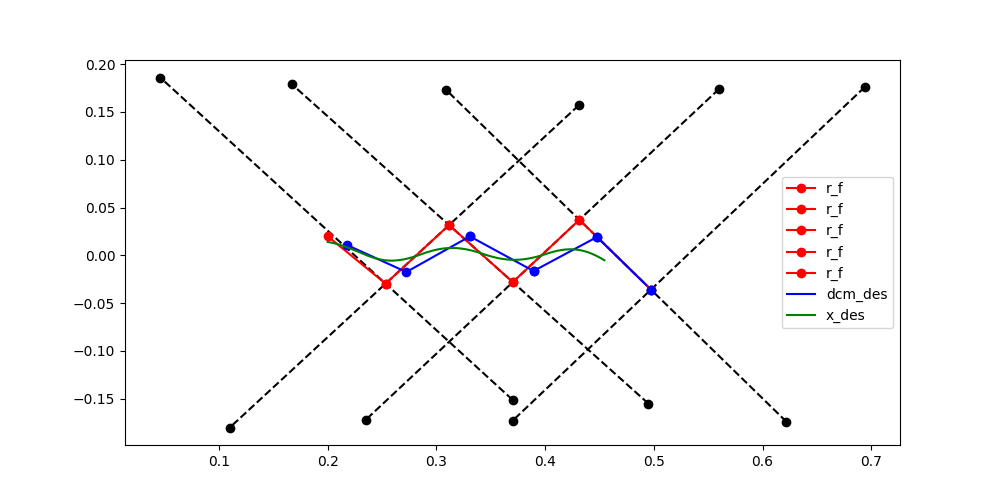

In [12]:
%matplotlib widget
# plot data
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100
fig, ax = plt.subplots()


for i in range(int(len(foot_plan)/2)):
    x_lst = [foot_plan[2*i].pos[X], foot_plan[2*i+1].pos[X]]
    y_lst = [foot_plan[2*i].pos[Y], foot_plan[2*i+1].pos[Y]]
    z_lst = [foot_plan[2*i].pos[Z], foot_plan[2*i+1].pos[Z]]
    ax.plot(x_lst, y_lst, 'ko--')

for i in range(int(len(r_f)-1)):
    x_lst = [r_f[i][X], r_f[i+1][X]]
    y_lst = [r_f[i][Y], r_f[i+1][Y]]
    z_lst = [r_f[i][Z], r_f[i+1][Z]]
    ax.plot(x_lst, y_lst, 'ro-', label="r_f")

for i in range(len(dcm_d_eos)-1):
    x_lst = [dcm_d_eos[i][X], dcm_d_eos[i+1][X]]
    y_lst = [dcm_d_eos[i][Y], dcm_d_eos[i+1][Y]]
    z_lst = [dcm_d_eos[i][Y], dcm_d_eos[i+1][Z]]
    ax.plot(x_lst, y_lst, 'bo')

x_lst = []
y_lst = []
z_lst = []
for i in range(len(dcm_d)):
    x_lst.append(dcm_d[i][X])
    y_lst.append(dcm_d[i][Y])
    z_lst.append(dcm_d[i][Z])
ax.plot(x_lst, y_lst, 'b-', label="dcm_des")

x_lst = []
y_lst = []
z_lst = []
for i in range(len(x_com)):
    x_lst.append(x_com[i][X])
    y_lst.append(x_com[i][Y])
    z_lst.append(x_com[i][Z])
ax.plot(x_lst, y_lst, 'g-', label="x_des")

plt.legend()
plt.show()


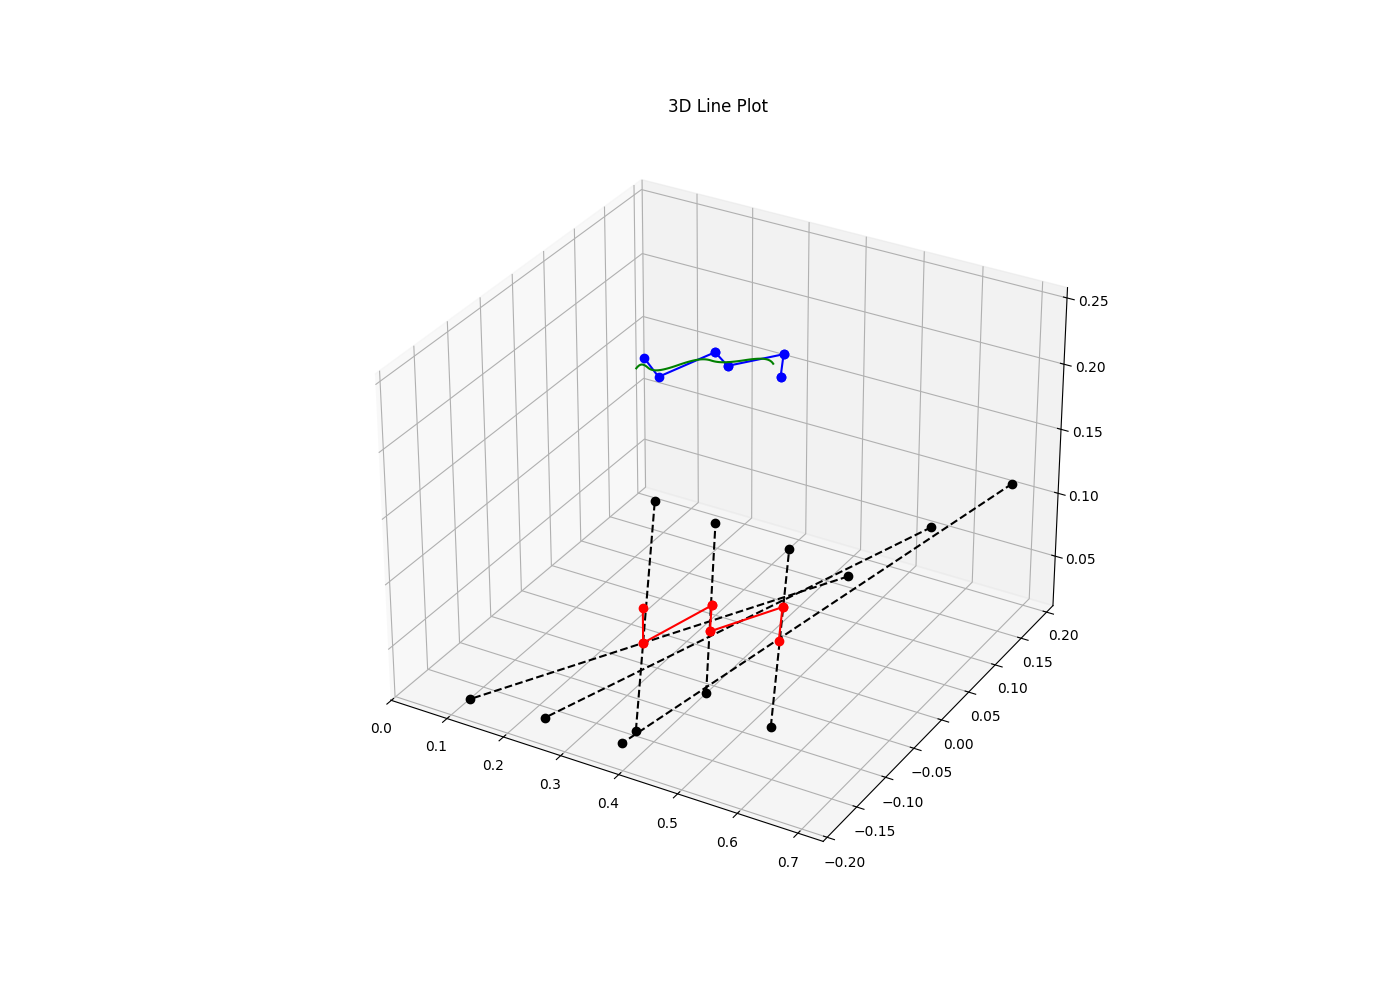

In [13]:

plt.rcParams['figure.figsize'] = [14, 10]
plt.rcParams['figure.dpi'] = 100
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = plt.axes(projection='3d')

for i in range(int(len(foot_plan)/2)):
    x_lst = [foot_plan[2*i].pos[X], foot_plan[2*i+1].pos[X]]
    y_lst = [foot_plan[2*i].pos[Y], foot_plan[2*i+1].pos[Y]]
    z_lst = [foot_plan[2*i].pos[Z], foot_plan[2*i+1].pos[Z]]
    ax.plot3D(x_lst, y_lst, z_lst, 'ko--')

for i in range(int(len(r_f)-1)):
    x_lst = [r_f[i][X], r_f[i+1][X]]
    y_lst = [r_f[i][Y], r_f[i+1][Y]]
    z_lst = [r_f[i][Z], r_f[i+1][Z]]
    ax.plot3D(x_lst, y_lst, z_lst, 'ro-', label="r_f")

for i in range(len(dcm_d_eos)-1):
    x_lst = [dcm_d_eos[i][X], dcm_d_eos[i+1][X]]
    y_lst = [dcm_d_eos[i][Y], dcm_d_eos[i+1][Y]]
    z_lst = [dcm_d_eos[i][Z], dcm_d_eos[i+1][Z]]
    ax.plot3D(x_lst, y_lst, z_lst, 'bo')

x_lst = []
y_lst = []
z_lst = []
for i in range(len(dcm_d)):
    x_lst.append(dcm_d[i][X])
    y_lst.append(dcm_d[i][Y])
    z_lst.append(dcm_d[i][Z])
ax.plot3D(x_lst, y_lst, z_lst, 'b-', label="dcm_des")

x_lst = []
y_lst = []
z_lst = []
for i in range(len(x_com)):
    x_lst.append(x_com[i][X])
    y_lst.append(x_com[i][Y])
    z_lst.append(x_com[i][Z])
# ax.plot(x_lst, y_lst, 'g-', label="x_des")
ax.plot3D(x_lst, y_lst, z_lst, 'green')
ax.set_title('3D Line Plot')
plt.show()